In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


EDA

In [3]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [4]:
print(df.shape)

(1338, 7)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [6]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [7]:
df.drop_duplicates(inplace=True)

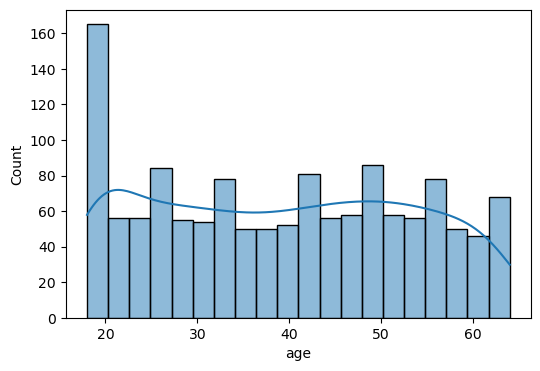

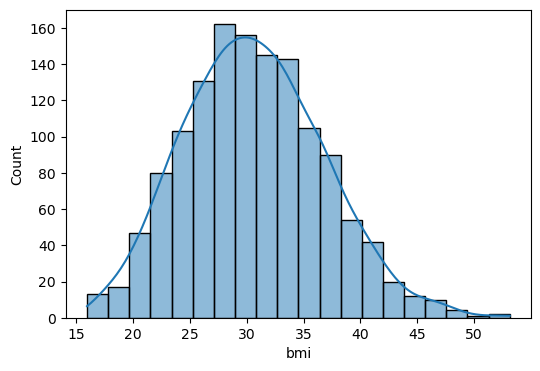

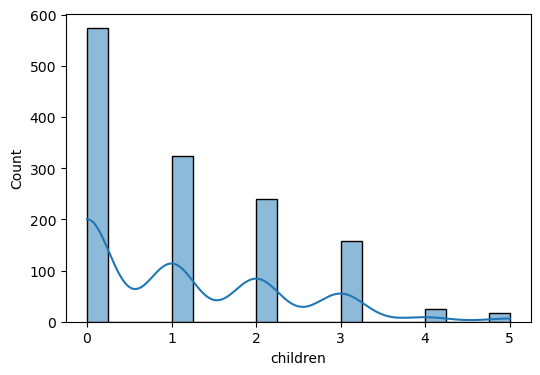

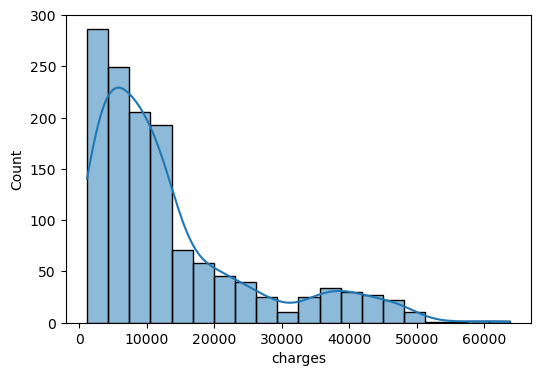

In [8]:
numeric_columns = ['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)

<Axes: xlabel='children', ylabel='count'>

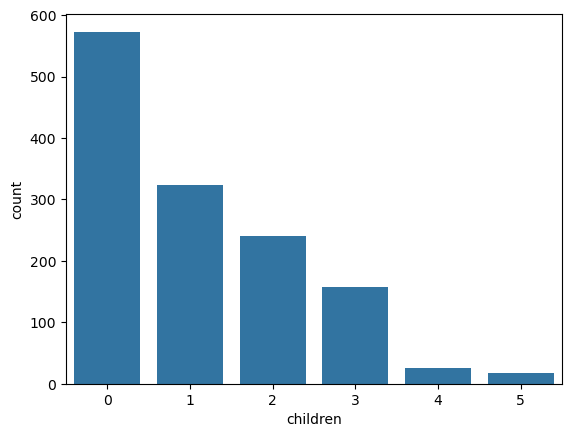

In [17]:
sns.countplot(x = df['children'])

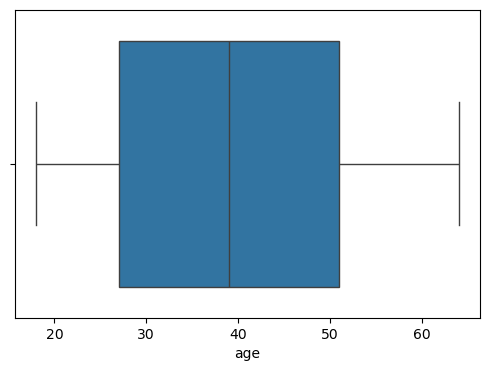

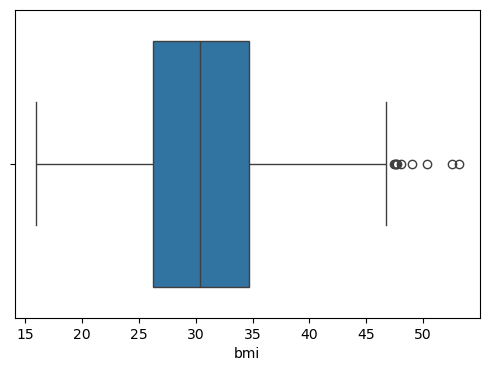

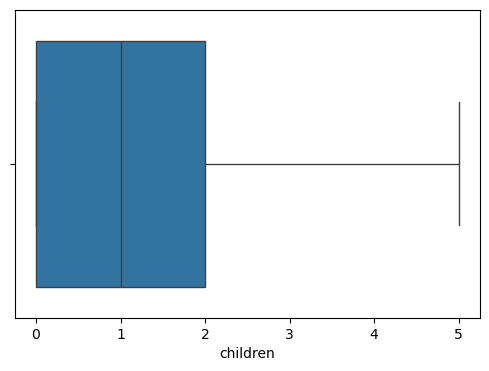

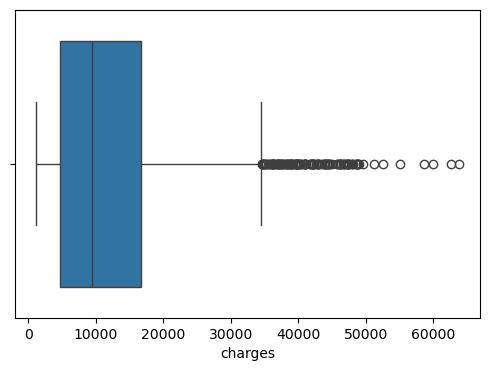

In [18]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])

<Axes: >

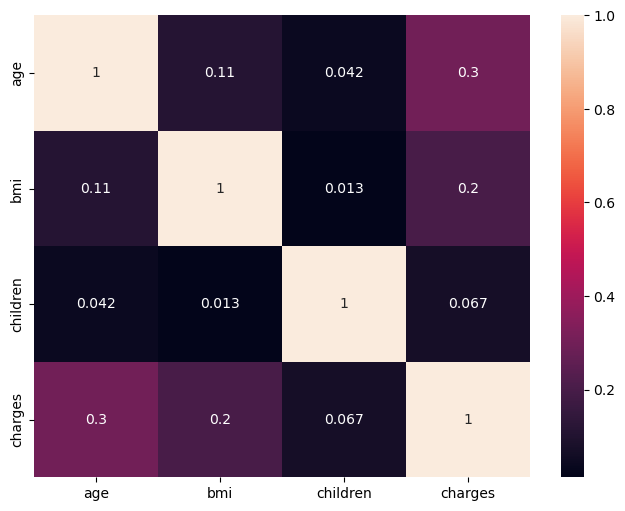

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

FEATURE ENGINEERING

In [9]:
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0,18.5,24.9,29.9,float("inf")],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

In [10]:
X = df.drop("charges", axis=1)
y = df["charges"]

TRAIN TEST SPLIT

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

PREPROCESSING

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  StandardScaler, OneHotEncoder

numeric_features = [ "age", "bmi", "children"]

categorical_features = ["sex", "smoker", "region", "bmi_category"]


preprocessor = ColumnTransformer(
           
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
        ])


PIPELINE

In [13]:
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
         ("preprocessor", preprocessor),
         ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [14]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("R² Score :", r2)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

R² Score : 0.8027245690414588
MAE : 4340.612852749378
MSE : 36250556.72495317
RMSE : 6020.843522709519


Adjusted R2

In [15]:
n = len(y_test)
p = X.shape[1]

adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("Adjusted R² :", adj_r2)

Adjusted R² : 0.7974133074387288


In [16]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score( pipeline, X, y, cv=5,scoring="r2")

print("Cross Validation R² Scores:")
print(cv_scores)

print("\nMean R² :", cv_scores.mean())

print("Standard Deviation :", cv_scores.std())

Cross Validation R² Scores:
[0.76342947 0.70615867 0.77979812 0.73699367 0.76116814]

Mean R² : 0.7495096151913997
Standard Deviation : 0.025624326170717967
